# 定理20　象徴臨場感方向性定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理20は何を言っているのか

### 原文の主張

定理4では、臨場感 $P$ が地形を曲げて落ち着き先を動かす、と述べました。定理20は、**象徴（旗・物語・儀式・広告など）への臨場感** $P_\sigma$ が、心の動きの **向き** をどう決めるかを調べます。

* $Z_u$：象徴が指す **目標集合**（LUB $u_\sigma$ に対応）。
* $D(x)\ge0$：状態 $x$ から目標までの **距離型の量**（$D=0\Leftrightarrow x\in Z_u$）。
* 象徴の効いた地形：$\tilde V_\sigma=V_0-\kappa\,q_\sigma P_\sigma\,s(D)$（$q_\sigma>0$ は接近の符号、$s$ は $D$ が小さいほど地形を下げる関数で $s'<0$）。
* 動き：$\dot x=-M\nabla\tilde V_\sigma$（$M$ は正定値の「移動しやすさ」の行列）。

2つの条件が **目標の外で一様に** 成り立つとします。

* **(20.A)**（反対勢力の上界）：$-\langle\nabla D,\,M\nabla V_0\rangle+\cdots\ \le\ b\,\|\nabla D\|_M^2$。素の地形などが目標方向と **逆向きに引く力** は、距離の勾配の大きさの $b$ 倍までに収まる。
* **(20.B)**（優越）：$\kappa\,q_\sigma P_\sigma\,(-s'(D))\ \ge\ b+c$（ある余裕 $c>0$）。象徴が呼ぶ力が、反対勢力の上界に対して **余裕 $c$ で勝っている**。

このとき、

$$
\kappa q_\sigma P_\sigma\bigl(-s'(D)\bigr)\ge b+c
\quad\Longrightarrow\quad
\langle\dot x,\,\nabla D\rangle_{M^{-1}}=-\dot D>0 .
$$

つまり **$\dot D\le-c\,\|\nabla D\|_M^2<0$**：距離 $D$ は **減り続ける**。さらに PL 型の条件 $\|\nabla D\|^2\ge2\mu D$ があれば指数収束 $D(t)\le D(0)\,e^{-2\mu c\,t}$ が出ます。

**但し書き。** 証明されるのは **「象徴が指す方向への成分を持つ」ことだけ** です。その方向が正しい、善い、真であるとは **言いません**。また「目標外に停留点がない」ことが暗黙に必要です。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $x\in\mathbb R^2$、$M=I$ | 状態、移動しやすさ | `x`、（$M=I$） |
| $V_0=\tfrac12\|x-v\|^2$ | 素の地形。谷は $v=(0,0)$ | `v`、`gV = x - v` |
| 目標集合 $Z_u=\bar B(u,R)$ | 象徴の指す目標（閉球）。$u=(2,0)$ | `u`、`R` |
| $D(x)=\tfrac14\bigl[(\|x-u\|^2-R^2)_+\bigr]^2$ | 目標球までの距離型。$D=0\Leftrightarrow\|x-u\|\le R$、$C^1$ | `D` |
| $\nabla D=(\|x-u\|^2-R^2)_+\,(x-u)$ | $D$ の勾配 | `gD` |
| $s(D)=-D$（$s'=-1$）、$P_\sigma=1$、$\kappa q_\sigma=K=\tfrac43$ | 呼ぶ力の強さ | `K` |
| $\dot x=-\nabla(V_0+K D)$ | 動き | `xdot = -gV - K*gD` |
| $b,c$ | Lean で使う値 $b=\tfrac13,\ c=1$（$b+c=K$） | `b_lean, c_lean` |

## 2. なぜこれが「定理20の例」と言えるのか

象徴が指す目標球 $Z_u$ の中心は $u=(2,0)$、素の地形の谷は $v=(0,0)$。この2つの **位置関係** で2つのケースを作ります。

* **ケース A（$R=2.5$）**：$\|u-v\|=2\le R$ なので、**素の谷 $v$ が目標球の内側** にあります。このとき素の地形は目標方向へ引く（または少なくとも逆らわない）ので、(20.A) は $b>0$ **任意** で成り立ち、(20.B) は $b+c\le K=\tfrac43$ で満たせます（Lean 側は $b=\tfrac13,\ c=1$）。PL 定数は $\mu=2R^2$。**定理の前提が全部成り立つ例** です。
* **ケース B（$R=0.5$）**：$\|u-v\|=2>R$、**素の谷 $v$ が目標球の外側** にあります。素の地形は目標球から遠ざかる方向 $v$ へ引きます。$x^*=(1,0)$ では素の地形の力 $-\nabla V_0=(-1,0)$ と象徴の力 $-K\nabla D=(+1,0)$ が **ちょうど釣り合う**（厳密な停留点）ので、そこで止まります。(20.A) は $x^*$ で $b\ge\tfrac43$ を要求するのに、(20.B) は $b+c\le\tfrac43$ を要求するので **両立しません**（$c\le0$）。**定理の前提を破った反例** です。

## 3. シミュレーション

In [1]:
# %% 準備
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
import numpy as np
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

u, v, K = np.array([2.0, 0.0]), np.zeros(2), 4 / 3
b_lean, c_lean = 1 / 3, 1.0                        # Lean 側の一般定理で使う (b, c), b+c=K

def simulate(R, x0=(-1.5, 2.0), dt=0.0005, steps=8000):
    x = np.array(x0, float); out = []
    for _ in range(steps):
        w = x - u; m = max(w @ w - R**2, 0.0)
        gD = m * w                                               # ∇D
        D = 0.25 * m**2
        gV = x - v                                               # ∇V0
        xdot = -gV - K * gD                                      # ẋ = −∇(V0 + K D)
        out.append((D, gD @ gD, gD @ xdot, -(gD @ gV), x.copy()))  # D, ‖∇D‖², Ḋ, (20.A)左辺(P=0)
        x = x + dt * xdot
    return np.array([o[:4] for o in out]), np.array([o[4] for o in out])

A, trajA = simulate(R=2.5)
B, trajB = simulate(R=0.5)

`simulate(R)` は $\dot x=-\nabla(V_0+KD)$ を Euler 法（$dt=0.0005$、8000 ステップ＝時間 4）で進めます。出発点は $x_0=(-1.5,\,2)$。各ステップで $D$、$\|\nabla D\|^2$、$\dot D$、(20.A) の左辺（$P=0$ の項）を記録します。

## 4. 図を読む

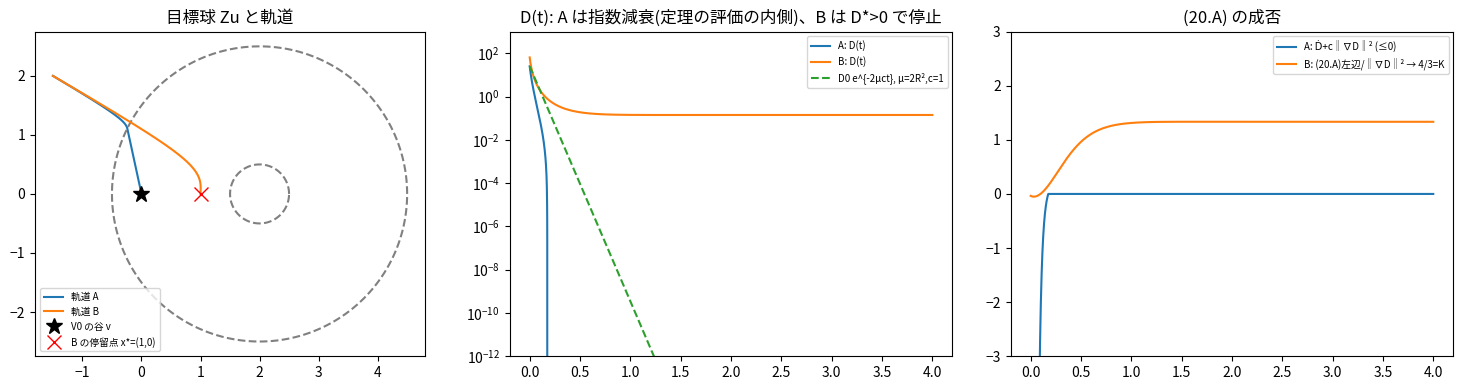

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
th = np.linspace(0, 2 * np.pi, 200)
for tr, R, lab in [(trajA, 2.5, "A"), (trajB, 0.5, "B")]:
    ax[0].plot(tr[:, 0], tr[:, 1], label=f"軌道 {lab}"); ax[0].plot(u[0] + R * np.cos(th), u[1] + R * np.sin(th), "--", c="gray")
ax[0].plot(*v, "k*", ms=12, label="V0 の谷 v"); ax[0].plot(1, 0, "rx", ms=10, label="B の停留点 x*=(1,0)")
ax[0].set_aspect("equal"); ax[0].legend(fontsize=7); ax[0].set_title("目標球 Zu と軌道")
t = 0.0005 * np.arange(len(A))
ax[1].semilogy(t, A[:, 0] + 1e-300, label="A: D(t)"); ax[1].semilogy(t, B[:, 0] + 1e-300, label="B: D(t)")
ax[1].semilogy(t, A[0, 0] * np.exp(-2 * (2 * 2.5**2) * c_lean * t), "--", label="D0 e^{-2μct}, μ=2R²,c=1")
ax[1].set_ylim(1e-12, 1e3); ax[1].legend(fontsize=7); ax[1].set_title("D(t): A は指数減衰(定理の評価の内側)、B は D*>0 で停止")
ax[2].plot(t, A[:, 2] + c_lean * A[:, 1], label="A: Ḋ+c‖∇D‖² (≤0)")
ax[2].plot(t, B[:, 3] / np.maximum(B[:, 1], 1e-12), label="B: (20.A)左辺/‖∇D‖² → 4/3=K")
ax[2].set_ylim(-3, 3); ax[2].legend(fontsize=7); ax[2].set_title("(20.A) の成否")
plt.tight_layout(); plt.show()

### 左：目標球 $Z_u$ と軌道（平面図）

灰色の破線の円が目標球です。**大きい円**が A（$R=2.5$、中心 $u=(2,0)$）、**小さい円**が B（$R=0.5$、同じ中心）。黒い星が素の谷 $v=(0,0)$、赤い × が B の停留点 $x^*=(1,0)$。

* **青（A）：** 左上 $(-1.5,2)$ から右下へ進み、大きい円の縁に **入って**（約 $(-0.24,\,1.11)$、時刻 $0.175$）から、素の谷 $v=(0,0)$（星）へ向かいます。目標球の **内側** に入り、$v$ は球の内側にあるので、そこで止まれば目標に着いています。
* **橙（B）：** 同じ出発点から、小さい円のほうへ向かいますが、**円に届く前の $x^*=(1,0)$（赤 ×）で止まります**。円の中心 $u$ までの距離は $1$、半径は $0.5$ なので、球の縁まではまだ $0.5$ あります。

### 中：$D(t)$（縦軸は対数）

* **青（A）：** $D$ は急落し、時刻 $0.2$ 弱で $0$（図では縦に落ちる）。**目標球に入った瞬間に $D=0$**（有限時間で到達）。緑の破線は定理の指数評価 $D_0e^{-2\mu ct}$（$\mu=2R^2=12.5,\ c=1$）で、**青はこの破線の内側（下）** にあります。
* **橙（B）：** 最初は下がりますが、約 $0.14$ で **水平** になり、動きません。厳密値は $D^*=\tfrac14\bigl[(1)^2-0.5^2\bigr]^2=\tfrac14(0.75)^2=\tfrac9{64}\approx0.1406$。

### 右：(20.A) の成否

* **青（A）：** $\dot D+c\|\nabla D\|^2$ を描いています。これが $\le0$ なら $\dot D\le-c\|\nabla D\|^2$（定理の下降）。最初は大きく負（図の下に突き抜ける）、球に入ると $D=0$ なので $0$。**ずっと $0$ 以下** です。
* **橙（B）：** (20.A) の左辺を $\|\nabla D\|^2$ で割った比です。これが **約 $1.33=\tfrac43=K$ に近づきます**。つまり (20.A) を満たすには $b\ge\tfrac43=K$ が必要で、すると (20.B) の $b+c\le K$ から $c\le0$。**余裕 $c>0$ が取れません。**

## 5. 数値確認

In [3]:
# %% 数値確認
outside = A[:, 0] > 1e-9
print("A: max(Ḋ + c‖∇D‖²) =", (A[outside, 2] + c_lean * A[outside, 1]).max(), " (≤0 なら (20.1) 成立), 最終 D =", A[-1, 0])
print("B: 最終 D =", B[-1, 0], " (厳密値 9/64 =", 9 / 64, ") 最終 x =", trajB[-1])
assert (A[outside, 2] + c_lean * A[outside, 1]).max() < 1e-9 and A[-1, 0] < 1e-6
assert abs(B[-1, 0] - 9 / 64) < 1e-3 and np.allclose(trajB[-1], [1.0, 0.0], atol=1e-2)   # 厳密な停留点 x*=(1,0)

A: max(Ḋ + c‖∇D‖²) = -0.001721754194652883  (≤0 なら (20.1) 成立), 最終 D = 0.0
B: 最終 D = 0.14062494757861788  (厳密値 9/64 = 0.140625 ) 最終 x = [1.00000010e+00 2.34472166e-04]


* A：目標球の外にいる間（$D>10^{-9}$）の $\max(\dot D+c\|\nabla D\|^2)\approx-0.0017\le0$、最終 $D=0$。
* B：最終 $D\approx0.140625$（厳密値 $9/64$ と一致）、最終位置 $\approx(1.0000001,\ 0.0002)$、つまり厳密な停留点 $x^*=(1,0)$ に止まる。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **象徴が心を動かす条件。** 原文は「国旗が、聖歌が、広告が心を動かす——その現象の成立条件を、不等式一本で書いたもの」と説明します。呼ぶ力が反対勢力に **余裕 $c$ で勝てば**、心は象徴の方向へ動く。
* **ケース B の読み方の一例。** 素の谷（日頃の習慣や欲求）が象徴の指す目標の外にあり、象徴の呼ぶ力がそれと釣り合う程度だと、**象徴に引かれても途中で止まります**。象徴の力が足りない（$K<b+c$ になる）ときは動かない。
* **方向≠真理。** 証明されるのは方向だけです。「象徴の指す方向が正しい」「善い」とは証明されません。同じ式が、悪意ある操作にも、導きにも使われうる——原文はこれを「武器にも盾にもなる」と述べます（整合性確認④）。
* 定理20は、定理21（偏りの谷）・定理22（高高度 LUB）へつながる方向づけの三定理の最初です。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem20_SymbolicPresence.lean`（`caseA`・`caseA_python_instance`・`caseB_constant_solution`・`caseB_no_valid_constants`）。

| | 内容 | 状態 |
| --- | --- | --- |
| ケース A（$v\in Z_u$） | 一般定理の全前提：(20.A) $b>0$ 任意、(20.B) $b+c\le K$、PL $\mu=2R^2$、誤差境界 $C=1/R$、$D$ の $C^1$ 勾配、と結論 | 証明済 |
| ケース B（$v\notin Z_u$） | $x^*=(1,0)$ が厳密な停留点、$D^*=\tfrac9{64}$、(20.A)(20.B) を同時に満たす $b,c>0$ は **存在しない** | 証明済 |
| Euler 離散化・図の軌道の形 | 数値のみ | 未証明 |

* もとの Python では $D=\tfrac12\mathrm{dist}^2$ でしたが、**$D=\tfrac14[(\|x-u\|^2-R^2)_+]^2$** に変更しました（$C^1$ で勾配が多項式になり、Lean で厳密に扱えるため）。$K=\tfrac43$ です。
* ケース B は「前提を外した場合の挙動」で、定理20そのものの反例ではありません。